In [ ]:
!pip install mlxtend
import warnings
warnings.filterwarnings("ignore")

ERROR: Operation cancelled by user


Saving Groceries_dataset.csv to Groceries_dataset (1).csv


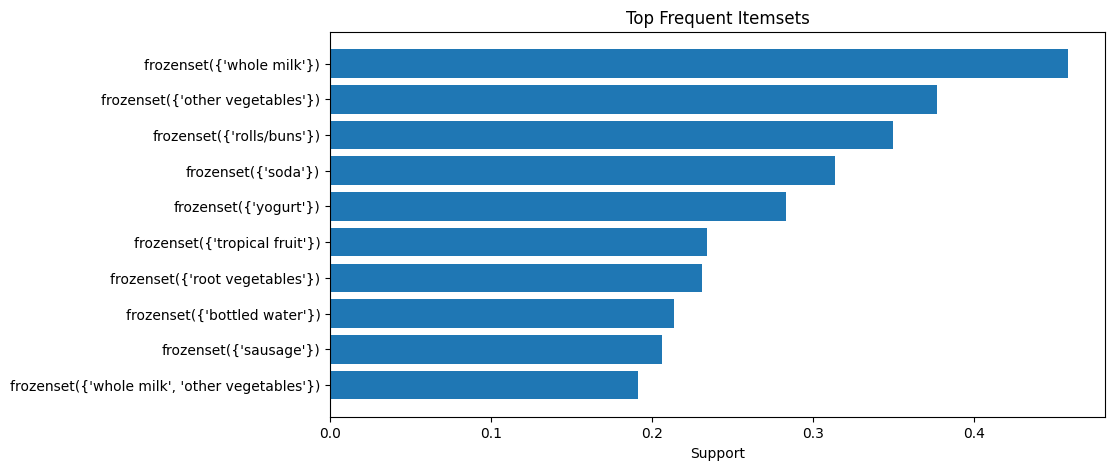

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Groceries_dataset.csv')
df.head()
# Combine transactions into basket format
basket = df.groupby(['Member_number', 'itemDescription'])['itemDescription'] \
            .count().unstack().fillna(0)

# Convert to binary (0/1)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

frequent_itemsets.sort_values('support', ascending=False).head(10)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules = rules.sort_values('lift', ascending=False)
rules.head()
strong_rules = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.2)
]

strong_rules.head(10)
top_items = frequent_itemsets.sort_values('support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(
    top_items['itemsets'].astype(str),
    top_items['support']
)
plt.xlabel("Support")
plt.title("Top Frequent Itemsets")
plt.gca().invert_yaxis()
plt.show()

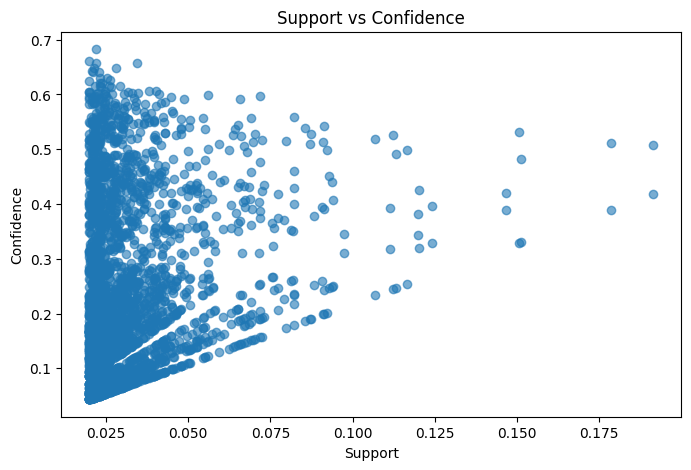

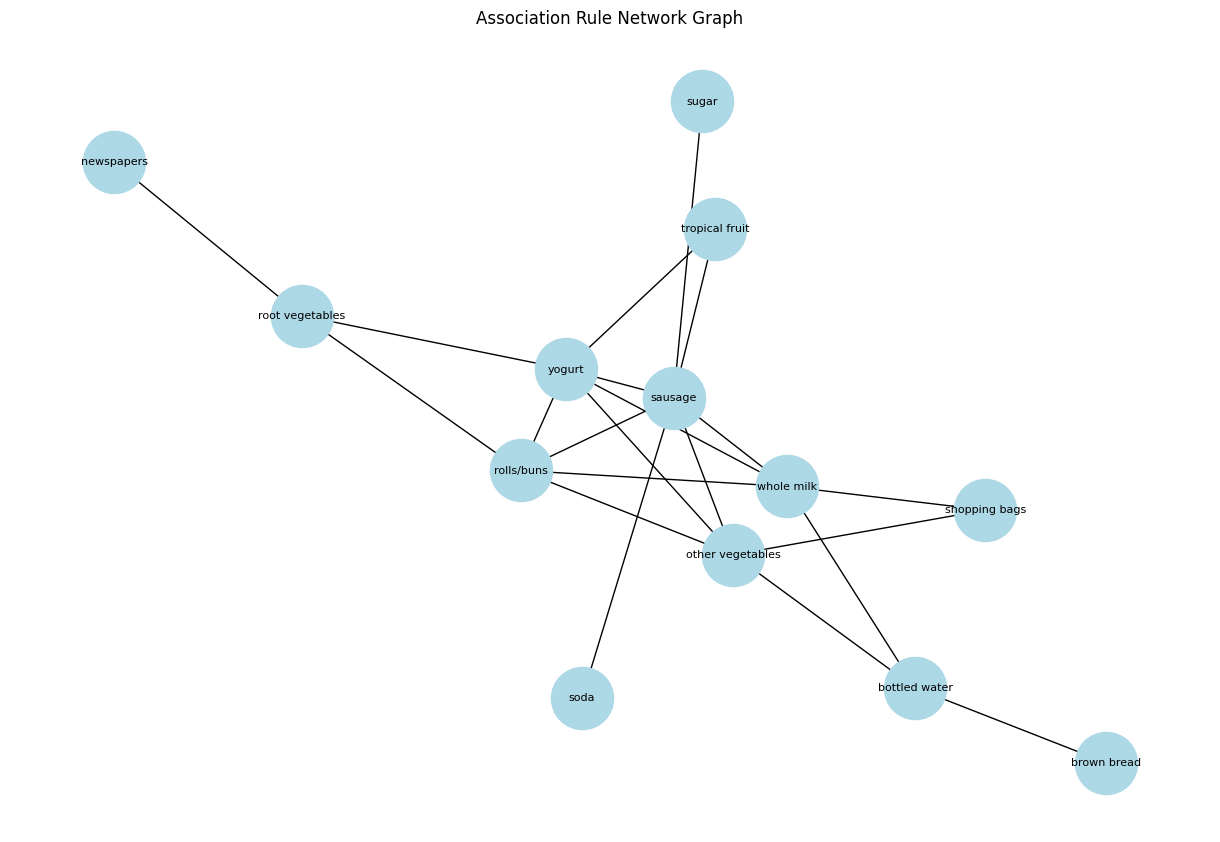

NOORIN NASHIKA M - 24BAD084


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(rules['support'], rules['confidence'], alpha=0.6)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()
G = nx.Graph()

for _, row in strong_rules.head(20).iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.8)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=8)
plt.title("Association Rule Network Graph")
plt.show()
print("NOORIN NASHIKA M - 24BAD084")

NOORIN NASHIKA M - 24BAD084

Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]


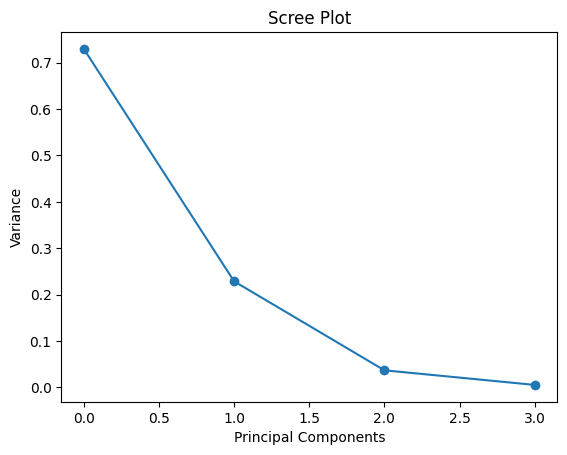

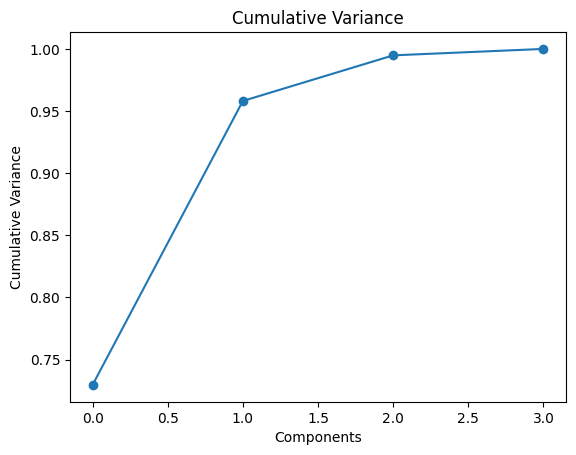

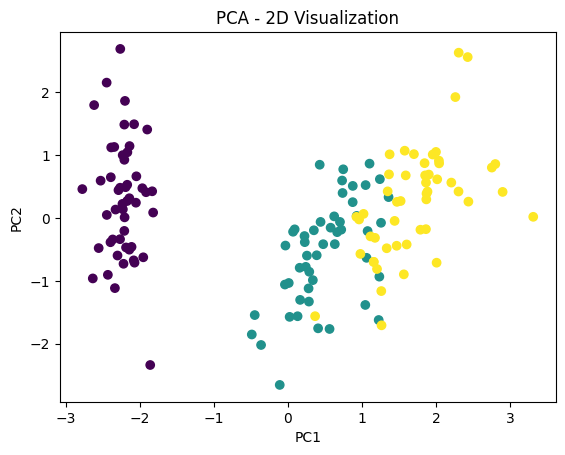

In [ ]:
print("NOORIN NASHIKA M - 24BAD084")

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

data = load_iris()
X = data.data
y = data.target

# -------------------------------
# Step 2: Standardization
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 3: Apply PCA
# -------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# Step 4: Explained Variance
# -------------------------------

print("\nExplained Variance Ratio:\n", pca.explained_variance_ratio_)

# -------------------------------
# Step 5: Scree Plot
# -------------------------------

plt.figure()
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

# -------------------------------
# Step 6: Cumulative Variance
# -------------------------------

cum_var = pca.explained_variance_ratio_.cumsum()
plt.figure()
plt.plot(cum_var, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

# -------------------------------
# Step 7: Reduce to 2D
# -------------------------------

pca2 = PCA(n_components=2)
X_reduced = pca2.fit_transform(X_scaled)

# -------------------------------
# Step 8: 2D Scatter Plot
# -------------------------------

plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Visualization")
plt.show()